In [1]:
print("Shivbaba")

Shivbaba


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import pickle

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [4]:

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



In [5]:
# Pretrained model
from transformers import pipeline


c:\Users\vikas\DATA SCIENCE\SPAM_TEXT_CLASSIFIER_NLP_PROJECT\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:

# --- NLTK setup ---
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vikas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vikas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vikas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [7]:
# --- Load dataset ---
df = pd.read_csv("SPAM_text_message_data.csv")
print(df.head())


  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


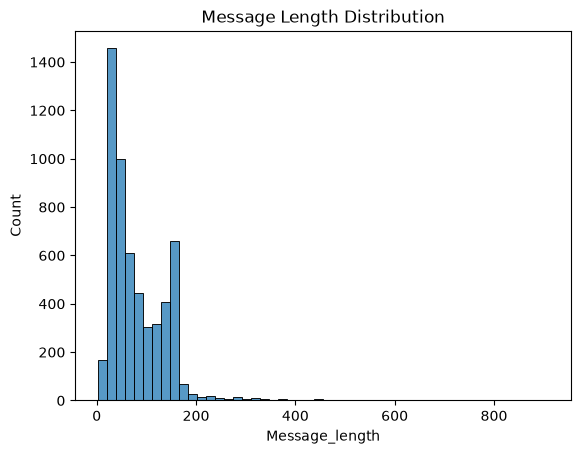

In [10]:
df['Message_length'] = df['Message'].apply(len)
sns.histplot(df['Message_length'], bins=50)
plt.title("Message Length Distribution")
plt.show()



In [14]:
# --- Preprocessing ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\d+", " number ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)



In [16]:
df['clean_text'] = df['Message'].apply(clean_text)



In [28]:
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

In [29]:
# --- Train/Test Split ---
X = df['clean_text']
y = df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [30]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)



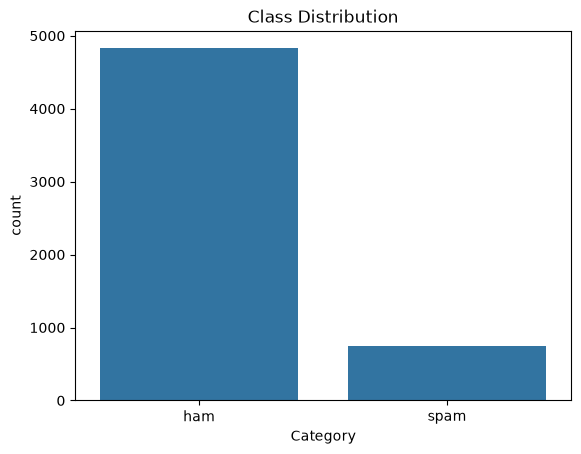

In [24]:

# --- EDA ---
sns.countplot(x='Category', data=df)
plt.title("Class Distribution")
plt.show()

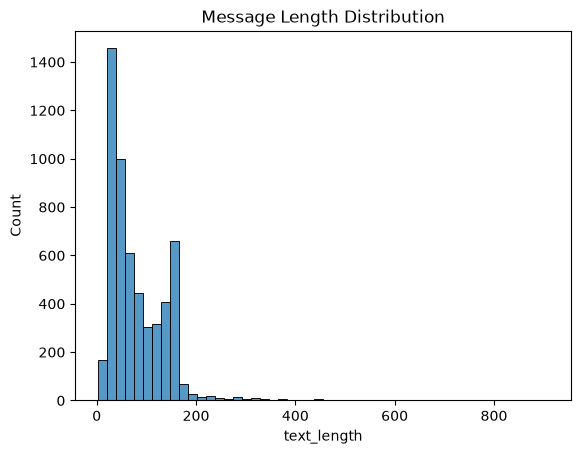

In [25]:


df['text_length'] = df['Message'].apply(len)
sns.histplot(df['text_length'], bins=50)
plt.title("Message Length Distribution")
plt.show()

In [31]:
# --- UDFs ---
def train_and_evaluate(model, model_name, X_train_vec, y_train, X_test_vec, y_test):
    """
    Train a given model and return evaluation metrics for both train and test sets.
    """
    model.fit(X_train_vec, y_train)
    y_pred_train = model.predict(X_train_vec)
    y_pred_test = model.predict(X_test_vec)

    metrics = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_pred_train),
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Train Precision": precision_score(y_train, y_pred_train),
        "Test Precision": precision_score(y_test, y_pred_test),
        "Train Recall": recall_score(y_train, y_pred_train),
        "Test Recall": recall_score(y_test, y_pred_test),
        "Train F1": f1_score(y_train, y_pred_train),
        "Test F1": f1_score(y_test, y_pred_test)
    }
    return metrics, model



In [32]:
def compare_models(models_dict, X_train_vec, y_train, X_test_vec, y_test):
    results = []
    trained_models = {}
    for name, model in models_dict.items():
        metrics, trained = train_and_evaluate(model, name, X_train_vec, y_train, X_test_vec, y_test)
        results.append(metrics)
        trained_models[name] = trained
    return pd.DataFrame(results), trained_models



In [33]:
# --- Train all models ---
models_dict = {
    "NaiveBayes": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "GradientBoosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}


In [34]:

results_df, trained_models = compare_models(models_dict, X_train_vec, y_train, X_test_vec, y_test)
print(results_df.sort_values(by="Test Accuracy", ascending=False))



c:\Users\vikas\DATA SCIENCE\SPAM_TEXT_CLASSIFIER_NLP_PROJECT\myenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:43:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 598, number of negative: 3859
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6431
[LightGBM] [Info] Number of data points in the train set: 4457, number of used features: 363
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134171 -> initscore=-1.864573
[LightGBM] [Info] Start training from score -1.864573
                Model  Train Accuracy  Test Accuracy  Train Precision  \
2                 SVM        0.998205       0.986547         0.993311   
9            LightGBM        0.999103       0.984753         1.000000   
8             XGBoost        0.994391       0.983857         1.000000   
0          NaiveBayes        0.986314       0.981166         1.000000   
3        RandomForest        0.999551       0.981166         1.000000   
6    Gr

In [36]:
# --- Save best model and vectorizer ---
best_model_name = results_df.sort_values(by="Test Accuracy", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]




In [40]:
from pathlib import Path

model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

with open(model_dir / "best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

pickle.dump(vectorizer, open(model_dir / "vectorizer.pkl", "wb"))
print(f"Best model saved: {best_model_name}")
pickle.dump(vectorizer, open("models/vectorizer.pkl", "wb"))


Best model saved: SVM


In [39]:
# --- Pretrained model comparison ---
classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english")
sample_text = "Congratulations! You have won a free lottery ticket."
print("Pretrained Prediction:", classifier(sample_text))


c:\Users\vikas\DATA SCIENCE\SPAM_TEXT_CLASSIFIER_NLP_PROJECT\myenv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vikas\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\vikas\DATA SCIENCE\SPAM_TEXT_CLASSIFIER_NLP_PR

Pretrained Prediction: [{'label': 'POSITIVE', 'score': 0.9998192191123962}]
